<a href="https://colab.research.google.com/github/Marcelo-Zambiazzo/Challenge-Allura-Store/blob/main/Challenge_Telecom_X_2da_parte.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    RocCurveDisplay, precision_recall_curve
)

In [60]:
df = pd.read_csv("clientes_normalizados.csv")

print("Dimensiones:", df.shape)
display(df.head())
df.info()
df.describe()

Dimensiones: (7267, 21)


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

,customer_SeniorCitizen,customer_tenure,account_Charges_Monthly,account_Charges_Total
count,7267.000000,7267.000000,7267.000000,7256.000000
mean,0.162653,32.346498,64.720098,2280.634213
std,0.369074,24.571773,30.129572,2268.632997
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.425000,400.225000
50%,0.000000,29.000000,70.300000,1391.000000
75%,0.000000,55.000000,89.875000,3785.300000
max,1.000000,72.000000,118.750000,8684.800000


Churn
No     5174
Yes    1869
Name: count, dtype: int64


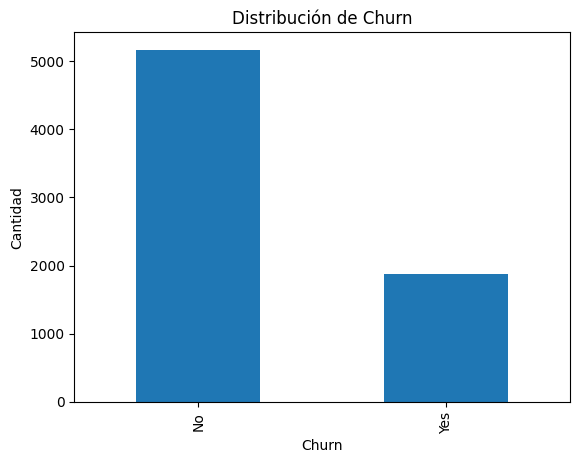

In [61]:
print(df["Churn"].value_counts())

plt.figure()
df["Churn"].value_counts().plot(kind="bar")
plt.title("Distribución de Churn")
plt.xlabel("Churn")
plt.ylabel("Cantidad")
plt.show()

In [62]:
# Eliminar nulos en Churn
df = df.dropna(subset=["Churn"])

# Eliminar ID
df = df.drop(columns=["customerID"])

# Convertir Churn a binaria
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Eliminar otros nulos
df = df.dropna()

In [63]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

In [64]:
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop="first")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

In [65]:
df.head()

,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,1,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,1,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,1,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [67]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),

}

results = {}

for name, model in models.items():

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:,1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "model": pipe
    }

results_df = pd.DataFrame(results).T
display(results_df)

,Accuracy,Precision,Recall,F1,ROC_AUC,model
Logistic Regression,0.802844,0.657267,0.540107,0.592955,0.845359,"(ColumnTransformer(transformers=[('num', Stand..."
Random Forest,0.78436,0.62156,0.483066,0.543631,0.821142,"(ColumnTransformer(transformers=[('num', Stand..."


<Figure size 640x480 with 0 Axes>

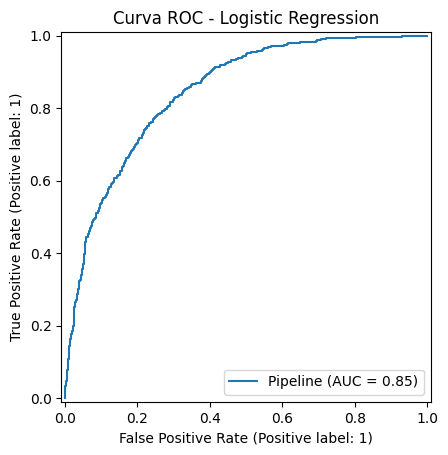

<Figure size 640x480 with 0 Axes>

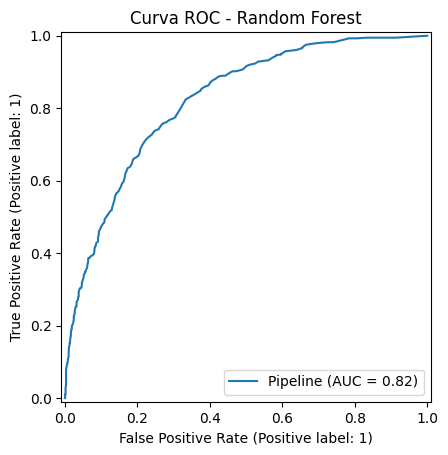

In [68]:
for name in results:
    plt.figure()
    RocCurveDisplay.from_estimator(results[name]["model"], X_test, y_test)
    plt.title(f"Curva ROC - {name}")
    plt.show()

In [69]:
rf_model = results["Random Forest"]["model"]

importances = rf_model.named_steps["classifier"].feature_importances_
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

display(feature_importance_df.head(15))

,feature,importance
3,num__account_Charges_Total,0.191118
2,num__account_Charges_Monthly,0.170190
1,num__customer_tenure,0.169279
28,cat__account_PaymentMethod_Electronic check,0.040759
10,cat__internet_InternetService_Fiber optic,0.039438
25,cat__account_Contract_Two year,0.030721
4,cat__customer_gender_Male,0.029116
26,cat__account_PaperlessBilling_Yes,0.025096
13,cat__internet_OnlineSecurity_Yes,0.024912
19,cat__internet_TechSupport_Yes,0.023649


<Figure size 640x480 with 0 Axes>

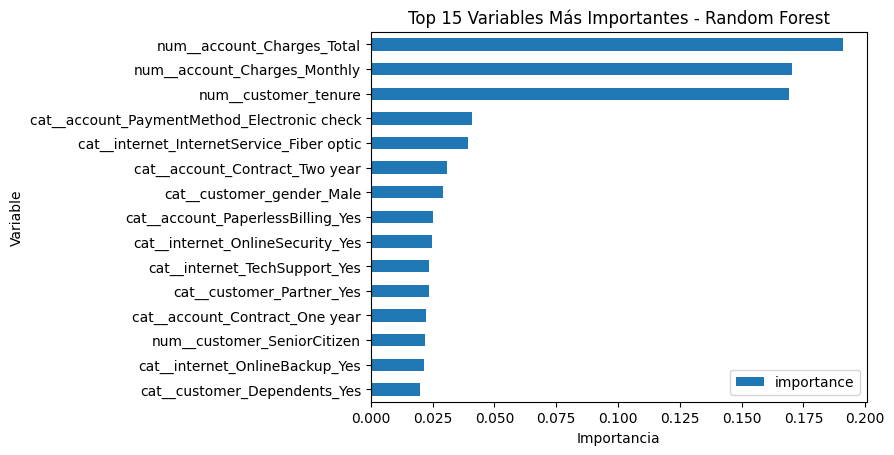

In [70]:
plt.figure()
feature_importance_df.head(15).sort_values(by="importance").plot(
    x="feature",
    y="importance",
    kind="barh"
)

plt.title("Top 15 Variables Más Importantes - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

In [71]:
best_model = results["Logistic Regression"]["model"]

feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = best_model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefficients
})

# Convertimos a Odds Ratio
coef_df["odds_ratio"] = np.exp(coef_df["coef"])

coef_df.sort_values(by="odds_ratio", ascending=False).head(15)

,feature,coef,odds_ratio
10,cat__internet_InternetService_Fiber optic,0.950172,2.586154
3,num__account_Charges_Total,0.642758,1.901719
28,cat__account_PaymentMethod_Electronic check,0.389401,1.476097
26,cat__account_PaperlessBilling_Yes,0.370992,1.449171
21,cat__internet_StreamingTV_Yes,0.315488,1.370928
23,cat__internet_StreamingMovies_Yes,0.223093,1.249937
9,cat__phone_MultipleLines_Yes,0.213012,1.237399
0,num__customer_SeniorCitizen,0.095794,1.100532
17,cat__internet_DeviceProtection_Yes,0.028707,1.029123
29,cat__account_PaymentMethod_Mailed check,0.012627,1.012707


In [72]:
pipe_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

param_grid = {
    "classifier__C": [0.1, 1, 5],
    "classifier__class_weight": [None, "balanced"]
}

grid = GridSearchCV(
    pipe_lr,
    param_grid,
    cv=3,
    scoring="roc_auc"
)

grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor ROC-AUC CV:", grid.best_score_)

best_model = grid.best_estimator_

Mejores parámetros: {'classifier__C': 5, 'classifier__class_weight': None}
Mejor ROC-AUC CV: 0.8457442038894212


In [73]:
y_prob = best_model.predict_proba(X_test)[:,1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = np.max(f1_scores)

print("Mejor threshold:", best_threshold)
print("Mejor F1:", best_f1)

Mejor threshold: 0.3056635972732276
Mejor F1: 0.6315018266602906


In [74]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = best_model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefficients,
    "abs_coef": np.abs(coefficients)
}).sort_values(by="abs_coef", ascending=False)

display(coef_df.head(15))

,feature,coef,abs_coef
10,cat__internet_InternetService_Fiber optic,1.477373,1.477373
1,num__customer_tenure,-1.419491,1.419491
25,cat__account_Contract_Two year,-1.259576,1.259576
2,num__account_Charges_Monthly,-0.867702,0.867702
3,num__account_Charges_Total,0.704223,0.704223
24,cat__account_Contract_One year,-0.695563,0.695563
8,cat__phone_MultipleLines_No phone service,-0.688940,0.688940
7,cat__phone_PhoneService_Yes,-0.592426,0.592426
21,cat__internet_StreamingTV_Yes,0.525229,0.525229
23,cat__internet_StreamingMovies_Yes,0.431306,0.431306


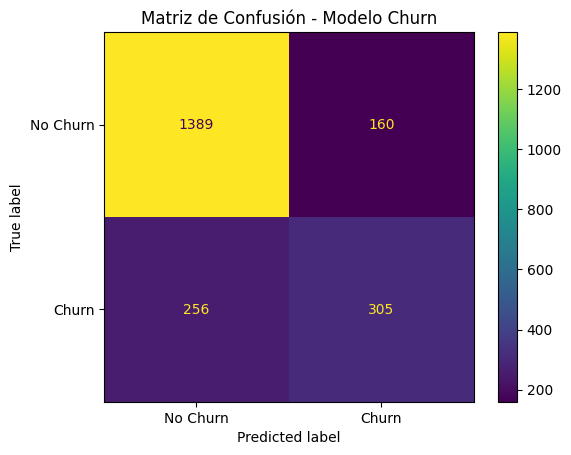

In [75]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["No Churn","Churn"])

disp.plot()
plt.title("Matriz de Confusión - Modelo Churn")
plt.show()

In [76]:
#alternativa para disminuir falsos negativos, depende de la decision estrategica y de costos
y_prob = best_model.predict_proba(X_test)[:,1]

threshold = 0.35

y_pred_custom = (y_prob >= threshold).astype(int)

In [77]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_custom)


array([[1230,  319],
       [ 161,  400]])

In [78]:
y_prob = best_model.predict_proba(X_test)[:,1]

In [79]:
threshold = 0.35

y_pred_035 = (y_prob >= threshold).astype(int)

In [80]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(y_test, y_pred_035)
precision = precision_score(y_test, y_pred_035)
recall = recall_score(y_test, y_pred_035)
f1 = f1_score(y_test, y_pred_035)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

Accuracy: 0.7725118483412322
Precision: 0.5563282336578581
Recall: 0.7130124777183601
F1 Score: 0.625
ROC AUC: 0.8454226693318327


Para disminuir los falsos negativos hay que ajustar el modelo, aumentando Recall (0.71 vs 0.54), pero sacrificamos accuracy (0.77 vs. 0.8), precision (0.55 vs 0.65), aunque mejora el F1 (0.625 vs 0.593), y ROC AUC casi no varía (0.8454 vs.0.8453), La decision depende de otros factotres de negocio (costos de retención, presupuesto, etc,), En este punto decido quedarme con el modelo de Regression Logistic.


In [81]:
import pickle

with open("modelo_churn_telecomX.pkl", "wb") as f:
    pickle.dump(best_model, f)

**Definición del Problema**

La empresa Telecom X busca anticipar la cancelación de clientes (churn) mediante modelos predictivos que permitan identificar clientes con alto riesgo y activar estrategias de retención.

**Descripción**

Desarrollo de modelo predictivo para identificar clientes con alta probabilidad de cancelación utilizando técnicas de Machine Learning.

**Herramientas**

* Python
* Pandas
* Scikit-learn
* Matplotlib / Seaborn

**Resultados**

* ROC-AUC: 0.85
* Identificación clara de drivers de churn
* Modelo listo para implementación productiva

**Hallazgos Clave**
Perfil de alto riesgo:

Cliente nuevo
Contrato mensual
Alta cuota mensual
Sin servicios adicionales de valor (soporte, seguridad)
Método de pago menos automático


**Recomendaciones Estratégicas**

Incentivar contratos anuales con descuento.
Implementar programa de fidelización en primeros 6 meses.
Ofrecer soporte técnico yseguridad en planes básicos.
Crear sistema de alerta mensual basado en churn score.